# Applying Linear Regression Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


There were a lot of zero's in the popularity and that was affecting the data, so we are going to form two linear regression models, one with the zero columns and one without the zero columns and compare the two. 

## Linear regression model with popularity 0's still attached

In [2]:
# 1. Load the transformed dataset
# Ensure 'df_transformed.csv' is in the same directory as your notebook
df_popularity0 = pd.read_csv('df_transformed.csv')

# 2. Define features (X) and target (y)
# We are predicting 'popularity' using all other available columns
target = 'popularity'
X0 = df_popularity0.drop(columns=[target])
y0 = df_popularity0[target]

# 3. Split the data (80% training, 20% testing)
X_train0, X_test0, y_train0, y_test0 = train_test_split(X0, y0, test_size=0.2, random_state=42)

# 4. Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train0, y_train0)
# 5. Make predictions on the test set
y_pred0 = lr_model.predict(X_test0)

# 6. Evaluate the model performance
mse0 = mean_squared_error(y_test0, y_pred0)
mae0 = mean_absolute_error(y_test0, y_pred0)
r20 = r2_score(y_test0, y_pred0)

print(f"--- Linear Regression Performance ---")
print(f"Mean Squared Error (MSE): {mse0:.4f}")
print(f"Mean Absolute Error (MAE): {mae0:.4f}")
print(f"R-squared (R2): {r20:.4f}")

--- Linear Regression Performance ---
Mean Squared Error (MSE): 1.0016
Mean Absolute Error (MAE): 0.8650
R-squared (R2): 0.0265


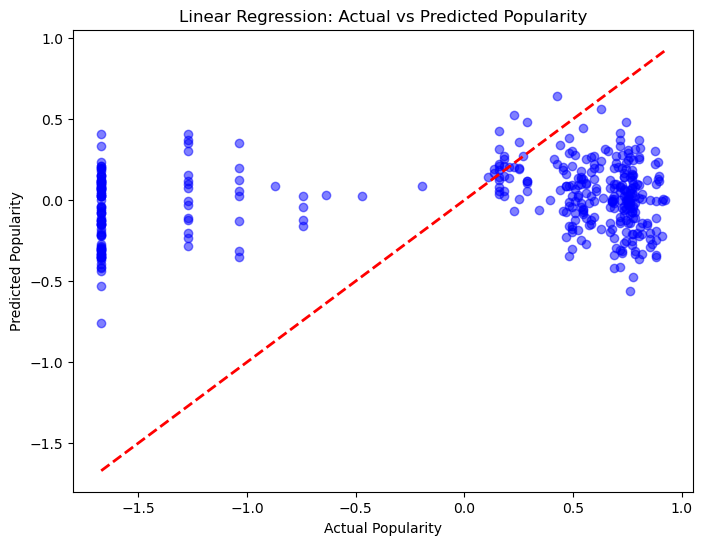

In [3]:
# 7. Visualize: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test0, y_pred0, alpha=0.5, color='blue')
# Add a diagonal line for reference (perfect prediction)
plt.plot([y_test0.min(), y_test0.max()], [y_test0.min(), y_test0.max()], 'r--', lw=2)
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Linear Regression: Actual vs Predicted Popularity')
plt.show()

In [4]:
# Inspecting Feature Importance (Coefficients)
coefficients = pd.DataFrame({'Feature': X0.columns, 'Coefficient': lr_model.coef_})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print("\n--- Feature Coefficients (Influence on Popularity) ---")
print(coefficients)


--- Feature Coefficients (Influence on Popularity) ---
                  Feature  Coefficient
17  track_genre_synth-pop     0.239642
16      track_genre_r-n-b     0.226818
5                  energy     0.167389
15        track_genre_pop     0.139482
13         time_signature     0.123519
1            acousticness     0.076709
14  track_genre_indie-pop     0.034621
3             duration_ms     0.020804
4            danceability     0.005219
6             speechiness     0.004848
7        instrumentalness     0.000225
11                    key    -0.009539
8                liveness    -0.012456
9                   tempo    -0.059163
0                 valence    -0.097074
2                loudness    -0.113738
12                   mode    -0.122374
10               explicit    -0.175119


The R2 score is very low on this linear regression model, and looking at the graph we can see that there are a lot of zeros in the data set, a possibility could be that removing the zeros could improve the R2 score of the new linear regression model

## Looking at why the R2 could be so low

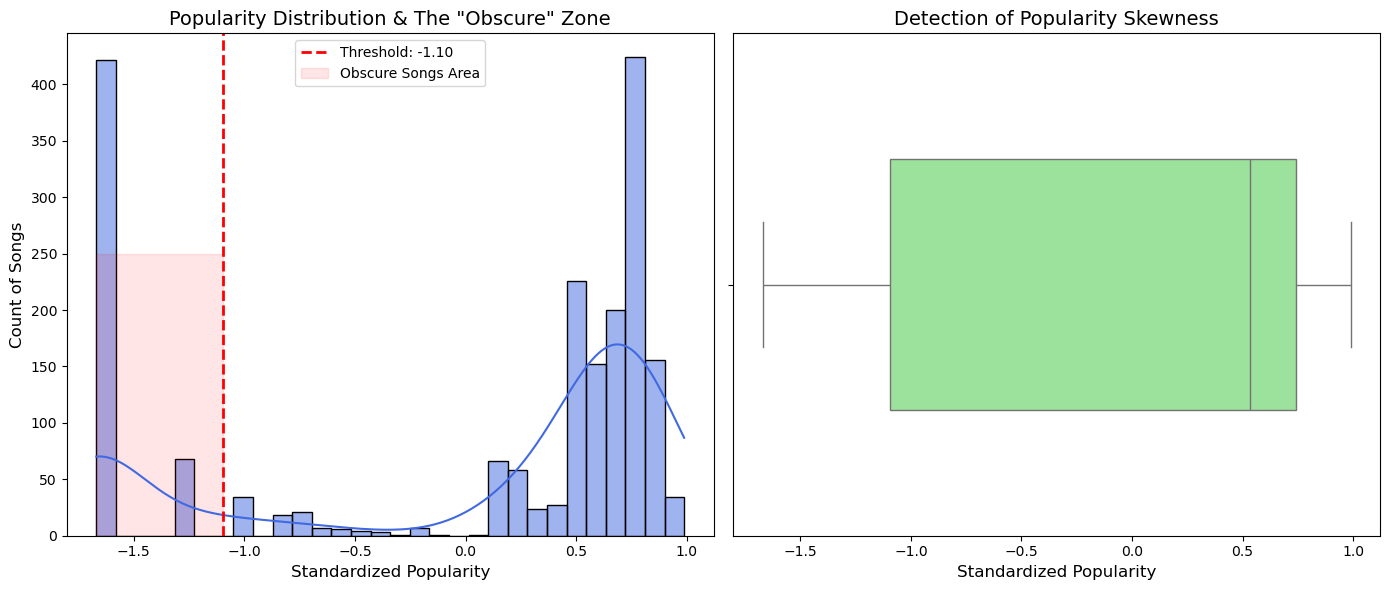

--- DATASET CLEANING SUMMARY ---
Original Song Count: 1960
Filtered Song Count: 1470
Total Songs Removed: 490 (Bottom 25%)
New Mean Popularity: 0.5382 (Was 0.00)
---------------------------------
Success: 'df_filtered.csv' created and ready for regression.


In [5]:
import seaborn as sns
# 1. Load the original transformed dataset
dfexample = pd.read_csv('df_transformed.csv')

# 2. Visualize the Problem: The "Long Tail" of Low Popularity
plt.figure(figsize=(14, 6))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(dfexample['popularity'], kde=True, color='royalblue', bins=30)
# Calculate the 25th percentile threshold
threshold = dfexample['popularity'].quantile(0.25)
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.2f}')
plt.fill_betweenx([0, 250], dfexample['popularity'].min(), threshold, color='red', alpha=0.1, label='Obscure Songs Area')
plt.title('Popularity Distribution & The "Obscure" Zone', fontsize=14)
plt.xlabel('Standardized Popularity', fontsize=12)
plt.ylabel('Count of Songs', fontsize=12)
plt.legend()

# Boxplot to show spread and density
plt.subplot(1, 2, 2)
sns.boxplot(x=dfexample['popularity'], color='lightgreen', width=0.5)
plt.title('Detection of Popularity Skewness', fontsize=14)
plt.xlabel('Standardized Popularity', fontsize=12)

plt.tight_layout()
plt.show()

# 3. Create a filtered DataFrame (Removing the bottom 25%)
df_filtered = dfexample[dfexample['popularity'] > threshold].copy()

# 4. Impact Summary for the team
print("--- DATASET CLEANING SUMMARY ---")
print(f"Original Song Count: {len(dfexample)}")
print(f"Filtered Song Count: {len(df_filtered)}")
print(f"Total Songs Removed: {len(dfexample) - len(df_filtered)} (Bottom 25%)")
print(f"New Mean Popularity: {df_filtered['popularity'].mean():.4f} (Was 0.00)")
print("---------------------------------")

# 5. Save the new dataset for the next modeling steps
df_filtered.to_csv('df_filtered.csv', index=False)
print("Success: 'df_filtered.csv' created and ready for regression.")

## Linear regression model with zeros taken out

In [6]:
# 1. Load the transformed dataset
# Ensure 'df_transformed.csv' is in the same directory as your notebook
df = pd.read_csv('df_filtered2.csv')

# 2. Define features (X) and target (y)
# We are predicting 'popularity' using all other available columns
target = 'popularity'
X = df.drop(columns=[target])
y = df[target]

# 3. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = lr_model.predict(X_test)

# 6. Evaluate the model performance
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Linear Regression Performance ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

--- Linear Regression Performance ---
Mean Squared Error (MSE): 0.0060
Mean Absolute Error (MAE): 0.0607
R-squared (R2): 0.4847


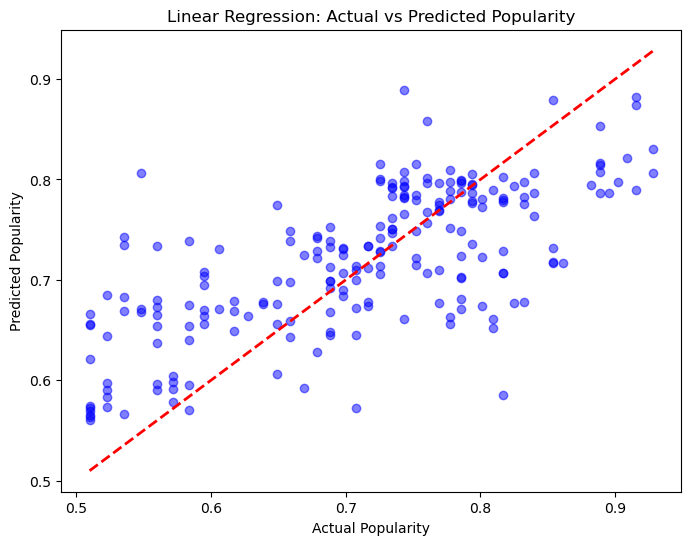

In [7]:
# 7. Visualize: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
# Add a diagonal line for reference (perfect prediction)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Linear Regression: Actual vs Predicted Popularity')
plt.show()

In [8]:
# 8. Inspect Feature Importance (Coefficients)
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print("\n--- Feature Coefficients (Influence on Popularity) ---")
print(coefficients)


--- Feature Coefficients (Influence on Popularity) ---
                  Feature  Coefficient
10               explicit     0.073719
15        track_genre_pop     0.070515
5                  energy     0.001827
12                   mode     0.001507
9                   tempo     0.001042
11                    key     0.000952
4            danceability     0.000649
7        instrumentalness     0.000078
8                liveness    -0.000271
2                loudness    -0.000325
6             speechiness    -0.001435
0                 valence    -0.003750
13         time_signature    -0.009617
1            acousticness    -0.010392
3             duration_ms    -0.013487
14  track_genre_indie-pop    -0.031645
17  track_genre_synth-pop    -0.068922
16      track_genre_r-n-b    -0.145848


## Comparison of two models

Here I am comparing the two models side by side, to showcase the difference in MSE, MAE, and R2 score

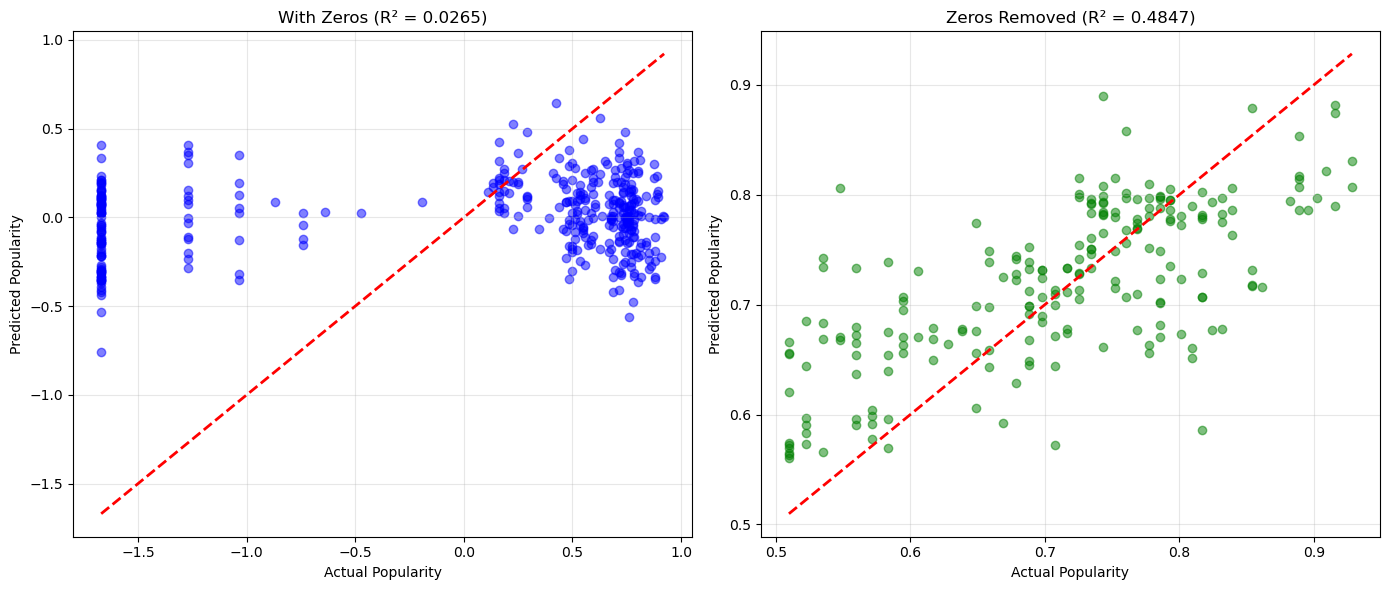


LINEAR REGRESSION MODEL COMPARISON
Metric                    With Zeros           Zeros Removed       
------------------------------------------------------------
MSE                       1.0016               0.0060              
MAE                       0.8650               0.0607              
R² Score                  0.0265               0.4847              


In [9]:
# Compare Actual vs Predicted plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: With zeros kept in
axes[0].scatter(y_test0, y_pred0, alpha=0.5, color='blue')
axes[0].plot([y_test0.min(), y_test0.max()], [y_test0.min(), y_test0.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title(f'With Zeros (R² = {r20:.4f})')
axes[0].grid(True, alpha=0.3)

# Right plot: With zeros removed
axes[1].scatter(y_test, y_pred, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Popularity')
axes[1].set_ylabel('Predicted Popularity')
axes[1].set_title(f'Zeros Removed (R² = {r2:.4f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print side-by-side comparison of MAE, MSE and R2
print("\n" + "="*60)
print("LINEAR REGRESSION MODEL COMPARISON")
print("="*60)
print(f"{'Metric':<25} {'With Zeros':<20} {'Zeros Removed':<20}")
print("-"*60)
print(f"{'MSE':<25} {mse0:<20.4f} {mse:<20.4f}")
print(f"{'MAE':<25} {mae0:<20.4f} {mae:<20.4f}")
print(f"{'R² Score':<25} {r20:<20.4f} {r2:<20.4f}")
print("="*60)

We can see that once we remove the zeros we are able to get a better R2 score and have a much better guess at the predicted popularity